# Установка и импорт библиотек

In [43]:
import numpy as np
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda import gpuarray
from pycuda.compiler import SourceModule
import time
import random
import matplotlib.pyplot as plt
import os
from google.colab import files

# Ядро CUDA для поиска подстрок

In [44]:
cuda_kernel = """
__global__ void search_kernel(unsigned char *buffer, int buffer_len,
                              int *pattern_lengths, int num_patterns,
                              int *pair_data, int *pair_offsets,
                              int *result_matrix, int *found_positions, int *found_count,
                              int find_all_positions)
{
    int idx = threadIdx.x + blockIdx.x * blockDim.x;
    int total_threads = blockDim.x * gridDim.x;

    for (int i = idx; i < buffer_len; i += total_threads)
    {
        unsigned char ch = buffer[i];
        int start_offset = pair_offsets[ch];
        int end_offset = pair_offsets[ch + 1];

        for (int j = start_offset; j < end_offset; j++)
        {
            int pattern_id = pair_data[j * 2];
            int k = pair_data[j * 2 + 1];
            int pos = i - k;

            if (pos >= 0)
            {
                int *row = result_matrix + pattern_id * buffer_len;
                atomicAdd(&row[pos], -1);
            }
        }
    }

    __syncthreads();

    if (find_all_positions == 1)
    {
        for (int i = idx; i < num_patterns; i += total_threads)
        {
            int pattern_len = pattern_lengths[i];
            int *row = result_matrix + i * buffer_len;

            for (int j = 0; j <= buffer_len - pattern_len; j++)
            {
                if (row[j] == 0)
                {
                    int pos = atomicAdd(found_count, 1);
                    found_positions[pos * 2] = i;
                    found_positions[pos * 2 + 1] = j;
                }
            }
        }
    }
    else
    {
        for (int i = idx; i < num_patterns; i += total_threads)
        {
            int pattern_len = pattern_lengths[i];
            int *row = result_matrix + i * buffer_len;
            int found_flag = 0;

            for (int j = 0; j <= buffer_len - pattern_len; j++)
            {
                if (row[j] == 0)
                {
                    found_flag = 1;
                    break;
                }
            }

            if (found_flag)
            {
                int pos = atomicAdd(found_count, 1);
                found_positions[pos] = i;
            }
        }
    }
}
"""

# Генерация входных данных

In [45]:
def generate_data(h, n, min_len, max_len):
    buffer = bytes([random.randint(0, 255) for _ in range(h)])
    patterns = []
    for _ in range(n):
        length = random.randint(min_len, max_len)
        pattern = bytes([random.randint(0, 255) for _ in range(length)])
        patterns.append(pattern)
    return buffer, patterns

# Сохранение входных данных в файл

In [46]:
def save_input_data(buffer, patterns, filename_prefix="input_data"):
    with open(f"{filename_prefix}_buffer.bin", "wb") as f:
        f.write(buffer)

    with open(f"{filename_prefix}_patterns.bin", "wb") as f:
        f.write(len(patterns).to_bytes(4, 'little'))
        for p in patterns:
            f.write(len(p).to_bytes(4, 'little'))
            f.write(p)

    with open(f"{filename_prefix}_info.txt", "w") as f:
        f.write(f"Размер буфера: {len(buffer)}\n")
        f.write(f"Количество подстрок: {len(patterns)}\n")
        f.write(f"Длины подстрок: {[len(p) for p in patterns]}\n")

# CPU реализация алгоритма

In [47]:
def search_cpu(buffer, patterns, find_all_positions=True):
    h = len(buffer)
    n = len(patterns)
    R = np.zeros((n, h), dtype=np.int32)
    for i, p in enumerate(patterns):
        R[i, :] = len(p)
    char_to_pairs = {}
    for idx, p in enumerate(patterns):
        for k, ch in enumerate(p):
            if ch not in char_to_pairs:
                char_to_pairs[ch] = []
            char_to_pairs[ch].append((idx, k))
    for i, ch in enumerate(buffer):
        if ch in char_to_pairs:
            for idx, k in char_to_pairs[ch]:
                pos = i - k
                if pos >= 0:
                    R[idx, pos] -= 1

    results = []
    if find_all_positions:
        for i in range(n):
            for j in range(h - len(patterns[i]) + 1):
                if R[i, j] == 0:
                    results.append((i, j))
    else:
        for i in range(n):
            pattern_len = len(patterns[i])
            for j in range(h - pattern_len + 1):
                if R[i, j] == 0:
                    results.append(i)
                    break

    return results

# GPU реализация с использованием PyCUDA

In [48]:
class GPUSearchPyCUDA:
    def __init__(self, patterns):
        self.patterns = patterns
        self.n = len(patterns)
        self.max_len = max(len(p) for p in patterns)
        self.char_to_pairs = {}
        for idx, p in enumerate(patterns):
            for k, ch in enumerate(p):
                if ch not in self.char_to_pairs:
                    self.char_to_pairs[ch] = []
                self.char_to_pairs[ch].append((idx, k))

        self.pair_offsets = np.zeros(258, dtype=np.int32)
        all_pairs = []
        for ch in range(256):
            if ch in self.char_to_pairs:
                self.pair_offsets[ch + 1] = self.pair_offsets[ch] + len(self.char_to_pairs[ch])
                for pair in self.char_to_pairs[ch]:
                    all_pairs.append(pair)
            else:
                self.pair_offsets[ch + 1] = self.pair_offsets[ch]

        self.pair_data = np.array(all_pairs, dtype=np.int32).flatten()

        self.mod = SourceModule(cuda_kernel)
        self.search_kernel = self.mod.get_function("search_kernel")

    def search(self, buffer, find_all_positions=True):
        h = len(buffer)

        buffer_gpu = cuda.mem_alloc(h)
        cuda.memcpy_htod(buffer_gpu, np.frombuffer(buffer, dtype=np.uint8))

        pattern_lengths = np.array([len(p) for p in self.patterns], dtype=np.int32)
        pattern_lengths_gpu = cuda.mem_alloc(self.n * 4)
        cuda.memcpy_htod(pattern_lengths_gpu, pattern_lengths)

        pair_data_gpu = cuda.mem_alloc(self.pair_data.nbytes)
        cuda.memcpy_htod(pair_data_gpu, self.pair_data)

        pair_offsets_gpu = cuda.mem_alloc(self.pair_offsets.nbytes)
        cuda.memcpy_htod(pair_offsets_gpu, self.pair_offsets)

        result_matrix = np.zeros((self.n, h), dtype=np.int32)
        for i, p in enumerate(self.patterns):
            result_matrix[i, :] = len(p)
        result_matrix_gpu = cuda.mem_alloc(result_matrix.nbytes)
        cuda.memcpy_htod(result_matrix_gpu, result_matrix)

        if find_all_positions:
            max_positions = self.n * h
            found_positions_gpu = cuda.mem_alloc(max_positions * 2 * 4)
        else:
            max_positions = self.n
            found_positions_gpu = cuda.mem_alloc(max_positions * 4)

        found_count_gpu = cuda.mem_alloc(4)
        cuda.memcpy_htod(found_count_gpu, np.array([0], dtype=np.int32))

        block_size = 256
        grid_size = (max(h, self.n) + block_size - 1) // block_size

        self.search_kernel(buffer_gpu, np.int32(h), pattern_lengths_gpu, np.int32(self.n),
                          pair_data_gpu, pair_offsets_gpu,
                          result_matrix_gpu, found_positions_gpu, found_count_gpu,
                          np.int32(1 if find_all_positions else 0),
                          block=(block_size, 1, 1), grid=(grid_size, 1))

        cuda.Context.synchronize()

        found_count = np.zeros(1, dtype=np.int32)
        cuda.memcpy_dtoh(found_count, found_count_gpu)

        results = []
        if found_count[0] > 0:
            if find_all_positions:
                found_positions = np.zeros(found_count[0] * 2, dtype=np.int32)
                cuda.memcpy_dtoh(found_positions, found_positions_gpu)
                for i in range(found_count[0]):
                    results.append((found_positions[i*2], found_positions[i*2+1]))
            else:
                found_patterns = np.zeros(found_count[0], dtype=np.int32)
                cuda.memcpy_dtoh(found_patterns, found_positions_gpu)
                results = found_patterns.tolist()

        return results

# Функция сравнения результатов

In [49]:
def compare_results(results_cpu, results_gpu, find_all_positions=True):
    set_cpu = set(results_cpu)
    set_gpu = set(results_gpu)

    return set_cpu == set_gpu

# Функция для измерения производительности при разных параметрах

In [50]:
def benchmark(h_list, n, min_len, max_len, save_data=True):
    cpu_times = []
    gpu_times = []
    speedups = []
    results_match = []

    for h in h_list:
        buffer, patterns = generate_data(h, n, min_len, max_len)

        if save_data:
            save_input_data(buffer, patterns, f"benchmark_h{h}")

        cpu_start = time.time()
        results_cpu = search_cpu(buffer, patterns, find_all_positions=True)
        cpu_time = time.time() - cpu_start
        cpu_times.append(cpu_time)

        gpu_searcher = GPUSearchPyCUDA(patterns)
        gpu_start = time.time()
        results_gpu = gpu_searcher.search(buffer, find_all_positions=True)
        gpu_time = time.time() - gpu_start
        gpu_times.append(gpu_time)

        speedups.append(cpu_time / gpu_time if gpu_time > 0 else 0)
        results_match.append(compare_results(results_cpu, results_gpu, find_all_positions=True))

        print(f"Буфер {h}: CPU = {cpu_time:.4f}с, GPU = {gpu_time:.4f}с, Ускорение = {cpu_time/gpu_time:.2f}x, Результаты совпадают: {results_match[-1]}")

    return cpu_times, gpu_times, speedups, results_match

# Функция для построения графиков

In [51]:
def plot_results(h_list, cpu_times, gpu_times, speedups):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(h_list, cpu_times, 'o-', label='CPU', color='blue', linewidth=2, markersize=8)
    axes[0].plot(h_list, gpu_times, 's-', label='GPU', color='red', linewidth=2, markersize=8)
    axes[0].set_xlabel('Размер буфера (h)', fontsize=12)
    axes[0].set_ylabel('Время выполнения (секунды)', fontsize=12)
    axes[0].set_title('Сравнение времени выполнения CPU и GPU', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].bar(range(len(h_list)), speedups, color='green', alpha=0.7, edgecolor='black')
    axes[1].set_xticks(range(len(h_list)))
    axes[1].set_xticklabels([str(h) for h in h_list])
    axes[1].set_xlabel('Размер буфера (h)', fontsize=12)
    axes[1].set_ylabel('Ускорение GPU (раз)', fontsize=12)
    axes[1].set_title('Ускорение GPU относительно CPU', fontsize=14)
    axes[1].axhline(y=1, color='red', linestyle='--', label='Порог ускорения 1x')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('benchmark_results.png', dpi=150)
    plt.show()

# Тестирование двух режимов поиска

In [52]:
def test_search_modes(h=5000, n=30, min_len=3, max_len=10):
    buffer, patterns = generate_data(h, n, min_len, max_len)

    save_input_data(buffer, patterns, "test_modes")

    print("\nРежим 1: Поиск всех позиций")
    cpu_start = time.time()
    results_cpu_all = search_cpu(buffer, patterns, find_all_positions=True)
    cpu_time_all = time.time() - cpu_start

    gpu_searcher = GPUSearchPyCUDA(patterns)
    gpu_start = time.time()
    results_gpu_all = gpu_searcher.search(buffer, find_all_positions=True)
    gpu_time_all = time.time() - gpu_start

    print(f"CPU время: {cpu_time_all:.4f}с, найдено вхождений: {len(results_cpu_all)}")
    print(f"GPU время: {gpu_time_all:.4f}с, найдено вхождений: {len(results_gpu_all)}")
    print(f"Результаты совпадают: {compare_results(results_cpu_all, results_gpu_all, find_all_positions=True)}")

    print("\nРежим 2: Поиск только факта присутствия")
    cpu_start = time.time()
    results_cpu_exist = search_cpu(buffer, patterns, find_all_positions=False)
    cpu_time_exist = time.time() - cpu_start

    gpu_start = time.time()
    results_gpu_exist = gpu_searcher.search(buffer, find_all_positions=False)
    gpu_time_exist = time.time() - gpu_start

    print(f"CPU время: {cpu_time_exist:.4f}с, найдено подстрок: {len(results_cpu_exist)}")
    print(f"GPU время: {gpu_time_exist:.4f}с, найдено подстрок: {len(results_gpu_exist)}")
    print(f"Результаты совпадают: {compare_results(results_cpu_exist, results_gpu_exist, find_all_positions=False)}")

    return results_cpu_all, results_gpu_all, results_cpu_exist, results_gpu_exist

# Основной запуск

Зависимость от размера буфера
Буфер 1000: CPU = 0.0066с, GPU = 0.0010с, Ускорение = 6.82x, Результаты совпадают: True
Буфер 5000: CPU = 0.0293с, GPU = 0.0017с, Ускорение = 16.74x, Результаты совпадают: True
Буфер 10000: CPU = 0.0605с, GPU = 0.0034с, Ускорение = 17.94x, Результаты совпадают: True
Буфер 20000: CPU = 0.1272с, GPU = 0.0074с, Ускорение = 17.13x, Результаты совпадают: True


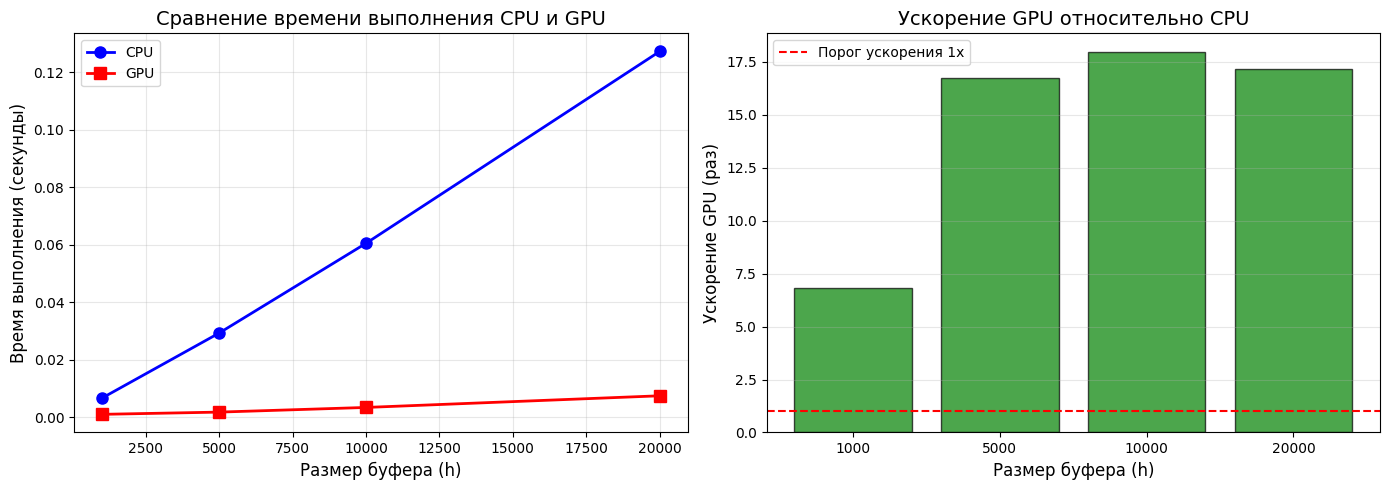


Зависимость от количества подстрок
Подстрок 20: CPU = 0.0446с, GPU = 0.0032с, Ускорение = 13.72x, Совпадают: True
Подстрок 50: CPU = 0.1063с, GPU = 0.0038с, Ускорение = 28.15x, Совпадают: True
Подстрок 100: CPU = 0.1998с, GPU = 0.0056с, Ускорение = 35.93x, Совпадают: True
Подстрок 150: CPU = 0.2970с, GPU = 0.0079с, Ускорение = 37.53x, Совпадают: True


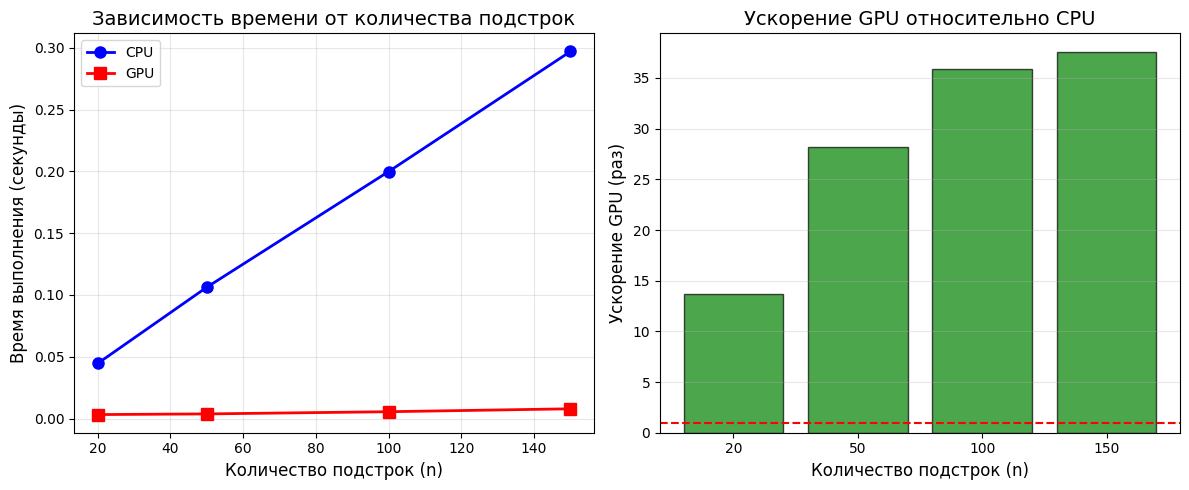

In [53]:
print("Зависимость от размера буфера")
h_values = [1000, 5000, 10000, 20000]
cpu_times, gpu_times, speedups, matches = benchmark(h_values, n=30, min_len=3, max_len=20, save_data=True)
plot_results(h_values, cpu_times, gpu_times, speedups)

print("\nЗависимость от количества подстрок")
def benchmark_by_patterns(h, n_list, min_len, max_len):
    cpu_times = []
    gpu_times = []
    speedups = []
    matches = []

    for n in n_list:
        buffer, patterns = generate_data(h, n, min_len, max_len)

        save_input_data(buffer, patterns, f"patterns_n{n}")

        cpu_start = time.time()
        results_cpu = search_cpu(buffer, patterns, find_all_positions=True)
        cpu_time = time.time() - cpu_start
        cpu_times.append(cpu_time)

        gpu_searcher = GPUSearchPyCUDA(patterns)
        gpu_start = time.time()
        results_gpu = gpu_searcher.search(buffer, find_all_positions=True)
        gpu_time = time.time() - gpu_start
        gpu_times.append(gpu_time)

        speedups.append(cpu_time / gpu_time if gpu_time > 0 else 0)
        matches.append(compare_results(results_cpu, results_gpu, find_all_positions=True))

        print(f"Подстрок {n}: CPU = {cpu_time:.4f}с, GPU = {gpu_time:.4f}с, Ускорение = {cpu_time/gpu_time:.2f}x, Совпадают: {matches[-1]}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(n_list, cpu_times, 'o-', label='CPU', color='blue', linewidth=2, markersize=8)
    plt.plot(n_list, gpu_times, 's-', label='GPU', color='red', linewidth=2, markersize=8)
    plt.xlabel('Количество подстрок (n)', fontsize=12)
    plt.ylabel('Время выполнения (секунды)', fontsize=12)
    plt.title('Зависимость времени от количества подстрок', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.bar(range(len(n_list)), speedups, color='green', alpha=0.7, edgecolor='black')
    plt.xticks(range(len(n_list)), [str(n) for n in n_list])
    plt.xlabel('Количество подстрок (n)', fontsize=12)
    plt.ylabel('Ускорение GPU (раз)', fontsize=12)
    plt.title('Ускорение GPU относительно CPU', fontsize=14)
    plt.axhline(y=1, color='red', linestyle='--')
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('benchmark_by_patterns.png', dpi=150)
    plt.show()

benchmark_by_patterns(h=10000, n_list=[20, 50, 100, 150], min_len=3, max_len=20)

# Тест с осмысленными данными для проверки режимов поиска

In [54]:
def test_with_meaningful_data():
    buffer = b"hello world hello test hello python"
    patterns = [b"hello", b"world", b"test", b"xyz"]

    print(f"Буфер: {buffer}")
    print(f"Подстроки: {patterns}")

    gpu_searcher = GPUSearchPyCUDA(patterns)

    print("\nРежим 1: Поиск всех позиций")
    results = gpu_searcher.search(buffer, find_all_positions=True)
    print(f"Найдено вхождений: {len(results)}")
    for pattern_id, pos in results:
        print(f"  Подстрока '{patterns[pattern_id].decode()}' на позиции {pos}")

    print("\nРежим 2: Поиск только факта присутствия")
    results = gpu_searcher.search(buffer, find_all_positions=False)
    print(f"Найдено подстрок: {len(results)}")
    for pattern_id in results:
        print(f"  Подстрока '{patterns[pattern_id].decode()}' присутствует")

    return results

test_with_meaningful_data()

Буфер: b'hello world hello test hello python'
Подстроки: [b'hello', b'world', b'test', b'xyz']

Режим 1: Поиск всех позиций
Найдено вхождений: 5
  Подстрока 'hello' на позиции 0
  Подстрока 'world' на позиции 6
  Подстрока 'hello' на позиции 12
  Подстрока 'test' на позиции 18
  Подстрока 'hello' на позиции 23

Режим 2: Поиск только факта присутствия
Найдено подстрок: 3
  Подстрока 'hello' присутствует
  Подстрока 'world' присутствует
  Подстрока 'test' присутствует


[0, 1, 2]